# 3. Modèles de Base (Baselines)

**Projet Semesteriel - Détection de Fake News COVID-19**  
**Niveau 4CS | Superviseur : Prof. Salem Trabelsi**

---

## Objectif

Ce notebook implémente et compare plusieurs modèles de classification traditionnels :
- **TF-IDF** comme représentation vectorielle du texte
- **SVM** (Support Vector Machine)
- **Régression Logistique**
- **Random Forest**
- **XGBoost**

Ces modèles servent de référence (baseline) pour évaluer les performances des modèles avancés (BERT).

## 3.1 Importation des bibliothèques

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.model_selection import cross_val_score, GridSearchCV

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost disponible.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost non installé. Installer avec : pip install xgboost")

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

XGBoost disponible.


In [2]:
# Ajouter src au path
sys.path.insert(0, os.path.join('..', 'src'))

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## 3.2 Chargement des données prétraitées

In [3]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# Charger les données
df_train = pd.read_csv(os.path.join(PROCESSED_DIR, 'train_processed.csv'))
df_val = pd.read_csv(os.path.join(PROCESSED_DIR, 'val_processed.csv'))
df_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'test_processed.csv'))

In [4]:
# Charger les métadonnées
with open(os.path.join(PROCESSED_DIR, 'metadata.json'), 'r') as f:
    metadata = json.load(f)

text_col = 'cleaned_text'
label_col = 'label_encoded'

print(f"Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}")
print(f"Label mapping : {metadata['label_mapping']}")

Train : 6420 | Val : 2140 | Test : 2140
Label mapping : {'fake': 0, 'real': 1}


In [5]:
# Préparer les données
X_train = df_train[text_col].fillna('')
X_val = df_val[text_col].fillna('')
X_test = df_test[text_col].fillna('')

y_train = df_train[label_col]
y_val = df_val[label_col]
y_test = df_test[label_col]

## 3.3 Extraction de features TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) transforme le texte en vecteurs numériques.  
Nous explorons différents hyperparamètres.

In [6]:
# Exploration des hyperparamètres TF-IDF
print("=" * 60)
print("EXPLORATION DES HYPERPARAMÈTRES TF-IDF")
print("=" * 60)

tfidf_configs = [
    {'max_features': 5000, 'ngram_range': (1, 1), 'name': 'unigrams_5k'},
    {'max_features': 10000, 'ngram_range': (1, 1), 'name': 'unigrams_10k'},
    {'max_features': 10000, 'ngram_range': (1, 2), 'name': 'uni+bigrams_10k'},
    {'max_features': 20000, 'ngram_range': (1, 2), 'name': 'uni+bigrams_20k'},
    {'max_features': 30000, 'ngram_range': (1, 3), 'name': 'uni+bi+trigrams_30k'},
]

EXPLORATION DES HYPERPARAMÈTRES TF-IDF


In [7]:
# Tester chaque configuration avec un modèle simple (Logistic Regression)
tfidf_results = []
for config in tfidf_configs:
    tfidf = TfidfVectorizer(
        max_features=config['max_features'],
        ngram_range=config['ngram_range'],
        sublinear_tf=True,
        min_df=2
    )
    X_tr = tfidf.fit_transform(X_train)
    X_v = tfidf.transform(X_val)
    
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr, y_train)
    val_acc = accuracy_score(y_val, lr.predict(X_v))
    val_f1 = f1_score(y_val, lr.predict(X_v), average='weighted')
    
    tfidf_results.append({
        'config': config['name'],
        'accuracy': val_acc,
        'f1_score': val_f1,
        'n_features': X_tr.shape[1]
    })
    print(f"  {config['name']:30s} | Acc: {val_acc:.4f} | F1: {val_f1:.4f} | Features: {X_tr.shape[1]}")

  unigrams_5k                    | Acc: 0.9234 | F1: 0.9234 | Features: 5000


  unigrams_10k                   | Acc: 0.9234 | F1: 0.9234 | Features: 6780


  uni+bigrams_10k                | Acc: 0.9271 | F1: 0.9271 | Features: 10000


  uni+bigrams_20k                | Acc: 0.9299 | F1: 0.9299 | Features: 20000


  uni+bi+trigrams_30k            | Acc: 0.9322 | F1: 0.9322 | Features: 30000


In [8]:
# Sélectionner la meilleure config
best_tfidf_config = max(tfidf_results, key=lambda x: x['f1_score'])
print(f"\nMeilleure configuration TF-IDF : {best_tfidf_config['config']}")


Meilleure configuration TF-IDF : uni+bi+trigrams_30k


In [9]:
# Utiliser la meilleure configuration TF-IDF
best_config = [c for c in tfidf_configs if c['name'] == best_tfidf_config['config']][0]

tfidf_vectorizer = TfidfVectorizer(
    max_features=best_config['max_features'],
    ngram_range=best_config['ngram_range'],
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF vectorizer créé avec {best_config['name']}")
print(f"Train shape : {X_train_tfidf.shape}")
print(f"Val shape   : {X_val_tfidf.shape}")
print(f"Test shape  : {X_test_tfidf.shape}")

TF-IDF vectorizer créé avec uni+bi+trigrams_30k
Train shape : (6420, 30000)
Val shape   : (2140, 30000)
Test shape  : (2140, 30000)


## 3.4 Entraînement des modèles de base

### 3.4.1 SVM (Support Vector Machine)

In [10]:
# SVM avec différentes valeurs de C
print("=" * 60)
print("SVM (LinearSVC)")
print("=" * 60)

svm_results = []
for C in [0.01, 0.1, 1.0, 5.0, 10.0]:
    svm = LinearSVC(C=C, max_iter=5000, random_state=42)
    svm.fit(X_train_tfidf, y_train)
    val_pred = svm.predict(X_val_tfidf)
    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred, average='weighted')
    svm_results.append({'C': C, 'accuracy': acc, 'f1': f1})
    print(f"  C={C:5.2f} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

best_C = max(svm_results, key=lambda x: x['f1'])['C']
print(f"\nMeilleur C pour SVM : {best_C}")

# Entraîner le meilleur SVM
svm_model = LinearSVC(C=best_C, max_iter=5000, random_state=42)
t0 = time()
svm_model.fit(X_train_tfidf, y_train)
svm_train_time = time() - t0
print(f"Temps d'entraînement : {svm_train_time:.2f}s")

SVM (LinearSVC)
  C= 0.01 | Accuracy: 0.8930 | F1: 0.8929
  C= 0.10 | Accuracy: 0.9322 | F1: 0.9323
  C= 1.00 | Accuracy: 0.9397 | F1: 0.9397
  C= 5.00 | Accuracy: 0.9421 | F1: 0.9421
  C=10.00 | Accuracy: 0.9411 | F1: 0.9411

Meilleur C pour SVM : 5.0


Temps d'entraînement : 0.04s


### 3.4.2 Régression Logistique

In [11]:
print("=" * 60)
print("RÉGRESSION LOGISTIQUE")
print("=" * 60)

lr_results = []
for C in [0.01, 0.1, 1.0, 5.0, 10.0]:
    lr = LogisticRegression(C=C, max_iter=2000, random_state=42, solver='lbfgs')
    lr.fit(X_train_tfidf, y_train)
    val_pred = lr.predict(X_val_tfidf)
    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred, average='weighted')
    lr_results.append({'C': C, 'accuracy': acc, 'f1': f1})
    print(f"  C={C:5.2f} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

best_C_lr = max(lr_results, key=lambda x: x['f1'])['C']
print(f"\nMeilleur C pour LR : {best_C_lr}")

lr_model = LogisticRegression(C=best_C_lr, max_iter=2000, random_state=42, solver='lbfgs')
t0 = time()
lr_model.fit(X_train_tfidf, y_train)
lr_train_time = time() - t0
print(f"Temps d'entraînement : {lr_train_time:.2f}s")

RÉGRESSION LOGISTIQUE
  C= 0.01 | Accuracy: 0.6776 | F1: 0.6361
  C= 0.10 | Accuracy: 0.8963 | F1: 0.8962
  C= 1.00 | Accuracy: 0.9322 | F1: 0.9322
  C= 5.00 | Accuracy: 0.9411 | F1: 0.9411
  C=10.00 | Accuracy: 0.9402 | F1: 0.9402

Meilleur C pour LR : 5.0


Temps d'entraînement : 0.04s


### 3.4.3 Random Forest

In [12]:
print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

t0 = time()
rf_model.fit(X_train_tfidf, y_train)
rf_train_time = time() - t0

val_pred_rf = rf_model.predict(X_val_tfidf)
acc_rf = accuracy_score(y_val, val_pred_rf)
f1_rf = f1_score(y_val, val_pred_rf, average='weighted')

print(f"Random Forest (n_estimators=200)")
print(f"  Accuracy : {acc_rf:.4f}")
print(f"  F1-score : {f1_rf:.4f}")
print(f"  Temps d'entraînement : {rf_train_time:.2f}s")

RANDOM FOREST


Random Forest (n_estimators=200)
  Accuracy : 0.9019
  F1-score : 0.9019
  Temps d'entraînement : 0.91s


### 3.4.4 XGBoost

In [13]:
if XGBOOST_AVAILABLE:
    print("=" * 60)
    print("XGBOOST")
    print("=" * 60)
    
    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    )
    
    t0 = time()
    xgb_model.fit(
        X_train_tfidf, y_train,
        eval_set=[(X_val_tfidf, y_val)],
        verbose=False
    )
    xgb_train_time = time() - t0
    
    val_pred_xgb = xgb_model.predict(X_val_tfidf)
    acc_xgb = accuracy_score(y_val, val_pred_xgb)
    f1_xgb = f1_score(y_val, val_pred_xgb, average='weighted')
    
    print(f"XGBoost (n_estimators=200, max_depth=6)")
    print(f"  Accuracy : {acc_xgb:.4f}")
    print(f"  F1-score : {f1_xgb:.4f}")
    print(f"  Temps d'entraînement : {xgb_train_time:.2f}s")
else:
    print("XGBoost non disponible. Passer cette étape.")
    xgb_model = None

XGBOOST


XGBoost (n_estimators=200, max_depth=6)
  Accuracy : 0.9075
  F1-score : 0.9075
  Temps d'entraînement : 31.00s


## 3.5 Comparaison des modèles sur le jeu de test

Nous évaluons tous les modèles sur le jeu de **test** (données non vues).

In [14]:
# Évaluer chaque modèle sur le jeu de test
models = {
    'SVM (LinearSVC)': svm_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
}
train_times = {
    'SVM (LinearSVC)': svm_train_time,
    'Logistic Regression': lr_train_time,
    'Random Forest': rf_train_time,
}

if XGBOOST_AVAILABLE and xgb_model is not None:
    models['XGBoost'] = xgb_model
    train_times['XGBoost'] = xgb_train_time

results = []
predictions = {}

print("=" * 80)
print("RÉSULTATS SUR LE JEU DE TEST")
print("=" * 80)

RÉSULTATS SUR LE JEU DE TEST


In [15]:
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Modèle': name,
        'Accuracy': acc,
        'F1-Score': f1,
        'Précision': prec,
        'Rappel': rec,
        'Temps (s)': train_times[name]
    })
    
    print(f"\n--- {name} ---")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Précision : {prec:.4f}")
    print(f"  Rappel    : {rec:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("TABLEAU RÉCAPITULATIF")
print("=" * 80)
print(results_df.to_string(index=False))


--- SVM (LinearSVC) ---
  Accuracy  : 0.9421
  F1-Score  : 0.9421
  Précision : 0.9421
  Rappel    : 0.9421

--- Logistic Regression ---
  Accuracy  : 0.9411
  F1-Score  : 0.9411
  Précision : 0.9412
  Rappel    : 0.9411

--- Random Forest ---
  Accuracy  : 0.9019
  F1-Score  : 0.9019
  Précision : 0.9046
  Rappel    : 0.9019

--- XGBoost ---
  Accuracy  : 0.9075
  F1-Score  : 0.9075
  Précision : 0.9090
  Rappel    : 0.9075

TABLEAU RÉCAPITULATIF
             Modèle  Accuracy  F1-Score  Précision   Rappel  Temps (s)
    SVM (LinearSVC)  0.942056  0.942056   0.942056 0.942056   0.041788
Logistic Regression  0.941121  0.941129   0.941151 0.941121   0.038083
      Random Forest  0.901869  0.901901   0.904583 0.901869   0.913499
            XGBoost  0.907477  0.907525   0.909000 0.907477  30.995517


## 3.6 Matrices de confusion

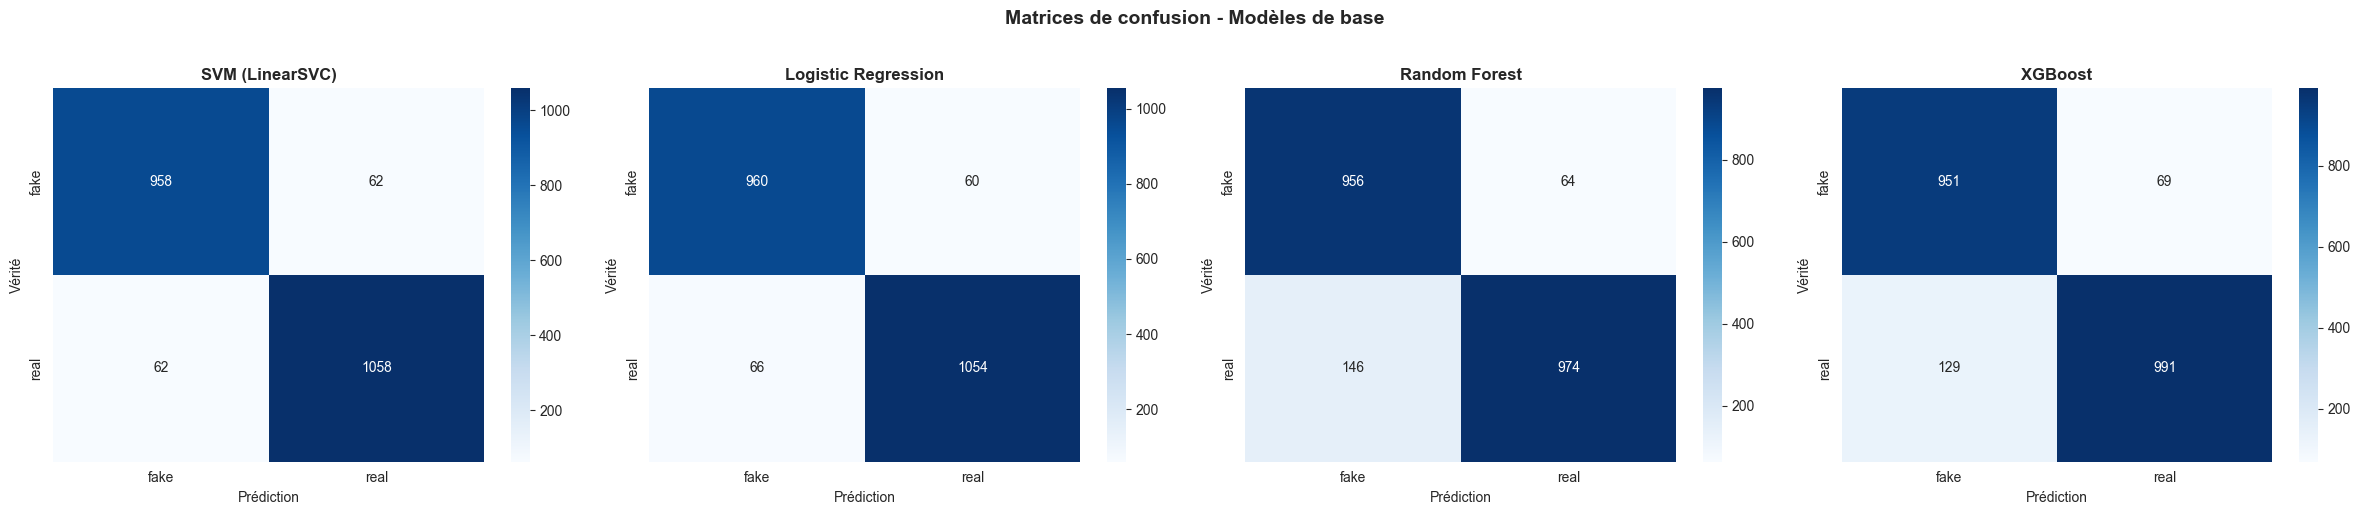

In [16]:
# Récupérer les noms des classes
label_names = list(metadata['label_mapping'].keys())

n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_names, yticklabels=label_names,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Prédiction')
    axes[idx].set_ylabel('Vérité')

plt.suptitle('Matrices de confusion - Modèles de base', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/baseline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.7 Rapports de classification détaillés

In [17]:
for name, y_pred in predictions.items():
    print("=" * 60)
    print(f"RAPPORT DE CLASSIFICATION : {name}")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=label_names))
    print()

RAPPORT DE CLASSIFICATION : SVM (LinearSVC)
              precision    recall  f1-score   support

        fake       0.94      0.94      0.94      1020
        real       0.94      0.94      0.94      1120

    accuracy                           0.94      2140
   macro avg       0.94      0.94      0.94      2140
weighted avg       0.94      0.94      0.94      2140


RAPPORT DE CLASSIFICATION : Logistic Regression
              precision    recall  f1-score   support

        fake       0.94      0.94      0.94      1020
        real       0.95      0.94      0.94      1120

    accuracy                           0.94      2140
   macro avg       0.94      0.94      0.94      2140
weighted avg       0.94      0.94      0.94      2140


RAPPORT DE CLASSIFICATION : Random Forest
              precision    recall  f1-score   support

        fake       0.87      0.94      0.90      1020
        real       0.94      0.87      0.90      1120

    accuracy                           0.90   

## 3.8 Analyse de l'importance des features (mots clés)

Quels mots sont les plus discriminants pour chaque classe ?

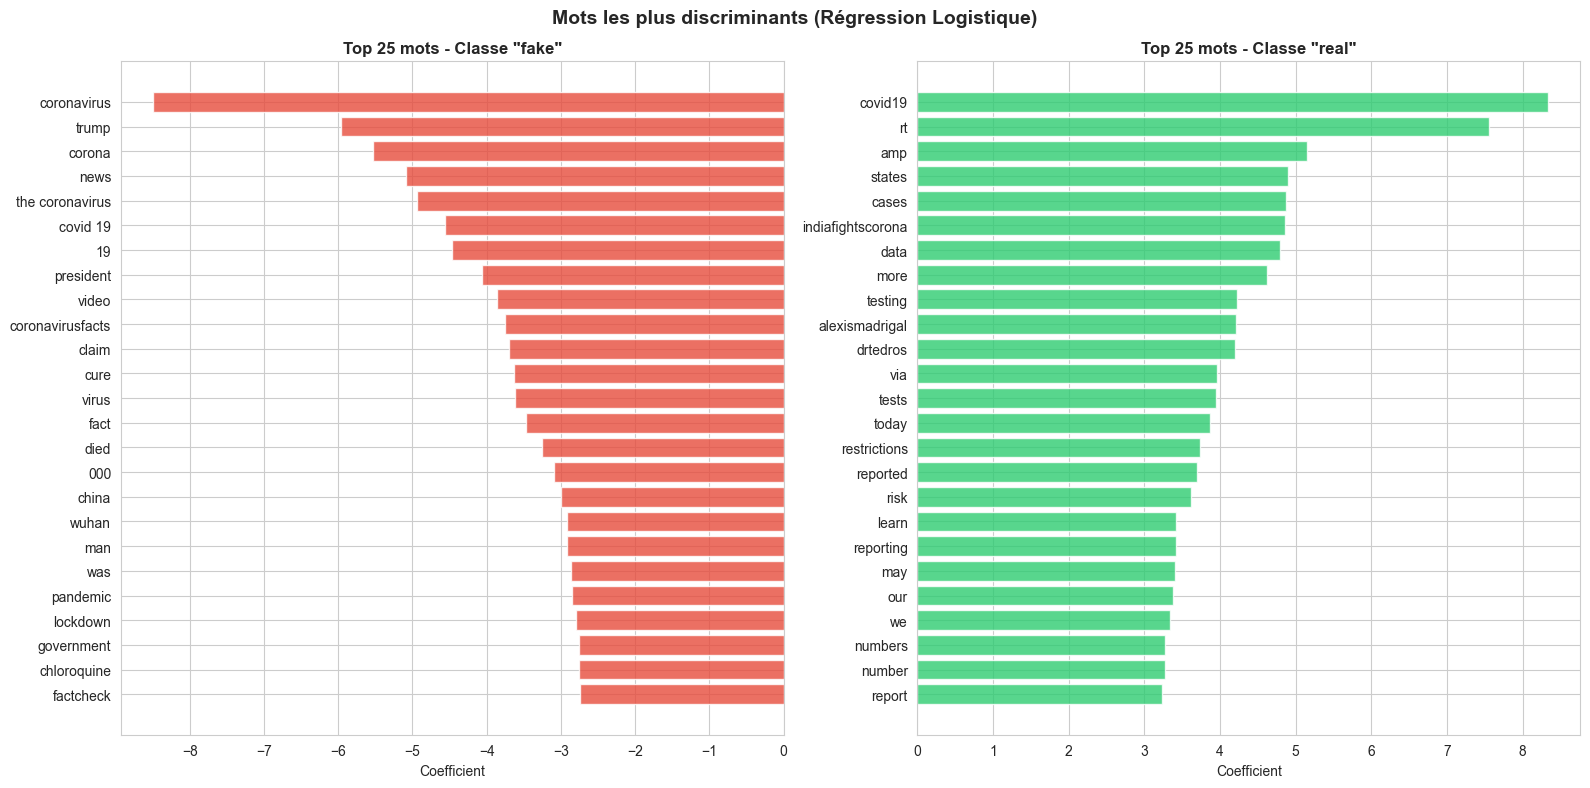

In [18]:
# Feature importance pour Logistic Regression
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Coefficients de la régression logistique
if hasattr(lr_model, 'coef_'):
    coefs = lr_model.coef_[0]
    
    # Top mots pour chaque classe
    top_n = 25
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Mots les plus associés à la classe 0 (négatifs)
    top_neg_idx = np.argsort(coefs)[:top_n]
    axes[0].barh(range(top_n), coefs[top_neg_idx], color='#e74c3c', alpha=0.8)
    axes[0].set_yticks(range(top_n))
    axes[0].set_yticklabels(feature_names[top_neg_idx])
    axes[0].invert_yaxis()
    axes[0].set_title(f'Top {top_n} mots - Classe "{label_names[0]}"', fontweight='bold')
    axes[0].set_xlabel('Coefficient')
    
    # Mots les plus associés à la classe 1 (positifs)
    top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
    axes[1].barh(range(top_n), coefs[top_pos_idx], color='#2ecc71', alpha=0.8)
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels(feature_names[top_pos_idx])
    axes[1].invert_yaxis()
    axes[1].set_title(f'Top {top_n} mots - Classe "{label_names[1]}"', fontweight='bold')
    axes[1].set_xlabel('Coefficient')
    
    plt.suptitle('Mots les plus discriminants (Régression Logistique)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3.9 Validation croisée

In [19]:
# Combiner train et val pour la validation croisée
X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

print("=" * 60)
print("VALIDATION CROISÉE (5-Fold)")
print("=" * 60)

cv_models = {
    'SVM': LinearSVC(C=best_C, max_iter=5000, random_state=42),
    'Logistic Regression': LogisticRegression(C=best_C_lr, max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

if XGBOOST_AVAILABLE:
    cv_models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1
    )

cv_results = []
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_val_tfidf, y_train_val, cv=5, scoring='f1_weighted', n_jobs=-1)
    cv_results.append({
        'Modèle': name,
        'F1 Moyen': scores.mean(),
        'Écart-type': scores.std(),
        'Scores': scores
    })
    print(f"  {name:25s} | F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

VALIDATION CROISÉE (5-Fold)


  SVM                       | F1: 0.9408 (+/- 0.0042)


  Logistic Regression       | F1: 0.9372 (+/- 0.0030)


  Random Forest             | F1: 0.9055 (+/- 0.0026)


  XGBoost                   | F1: 0.9111 (+/- 0.0039)


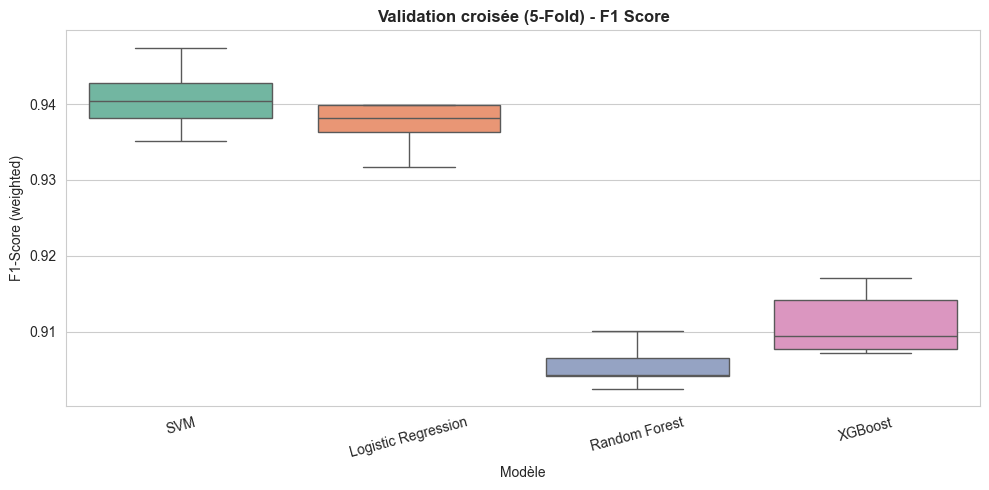

In [20]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = pd.DataFrame([
    {'Modèle': r['Modèle'], 'Fold': f'Fold {i+1}', 'F1': s}
    for r in cv_results
    for i, s in enumerate(r['Scores'])
])
sns.boxplot(data=cv_data, x='Modèle', y='F1', palette='Set2', ax=ax)
ax.set_title('Validation croisée (5-Fold) - F1 Score', fontweight='bold')
ax.set_ylabel('F1-Score (weighted)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.10 Visualisation comparative des performances

(0.0, 1.1)

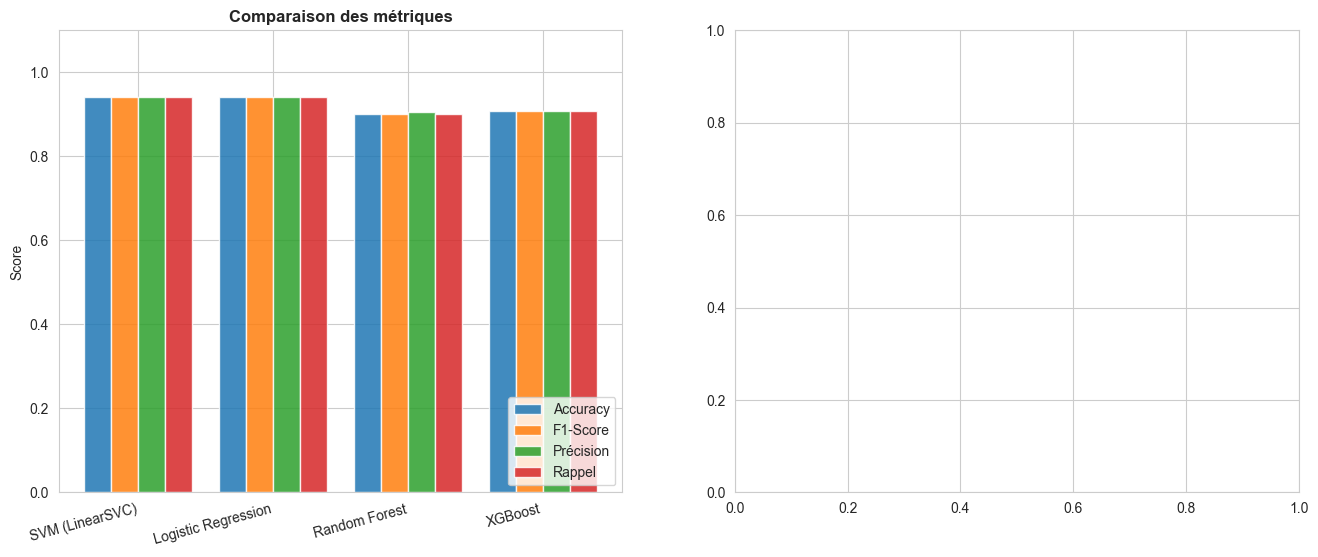

In [21]:
# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Métriques
metrics = ['Accuracy', 'F1-Score', 'Précision', 'Rappel']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, results_df[metric], width, label=metric, alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(results_df['Modèle'], rotation=15, ha='right')
axes[0].set_title('Comparaison des métriques', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.1)

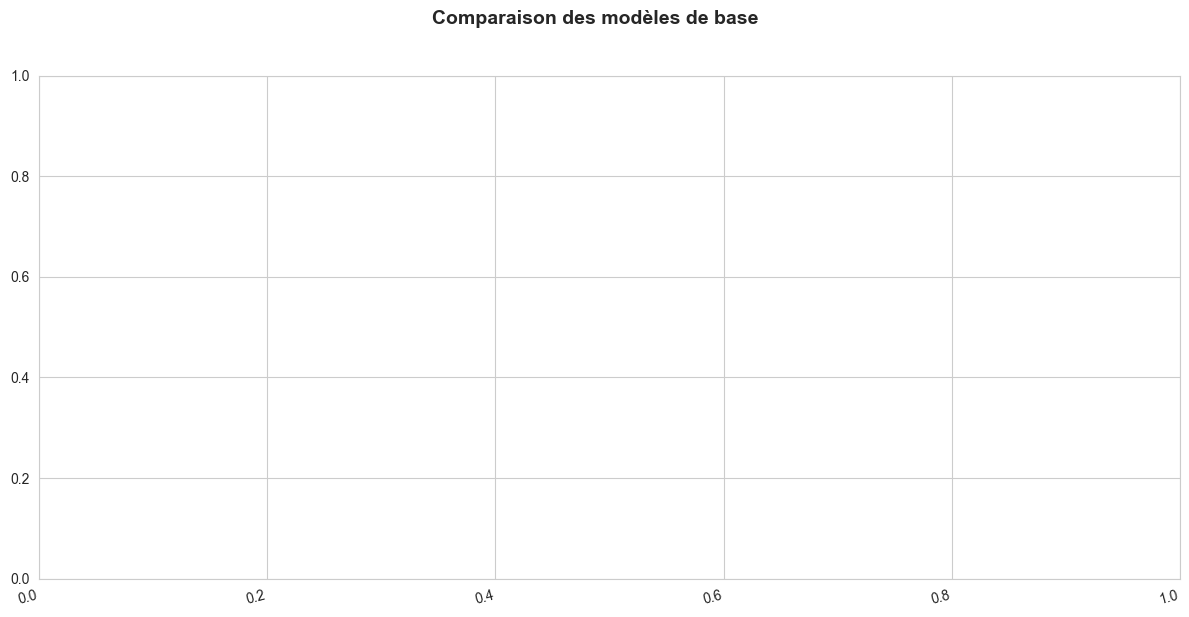

In [22]:
# Temps d'entraînement
axes[1].bar(results_df['Modèle'], results_df['Temps (s)'], color='steelblue', alpha=0.8)
axes[1].set_title('Temps d\'entraînement', fontweight='bold')
axes[1].set_ylabel('Secondes')
plt.xticks(rotation=15, ha='right')

plt.suptitle('Comparaison des modèles de base', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.11 Sauvegarde des modèles et résultats

In [23]:
import pickle

# Sauvegarder les modèles
for name, model in models.items():
    model_filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.pkl'
    filepath = os.path.join(MODELS_DIR, model_filename)
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"Modèle sauvegardé : {filepath}")

# Sauvegarder le vectorizer TF-IDF
tfidf_path = os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl')
with open(tfidf_path, 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print(f"TF-IDF vectorizer sauvegardé : {tfidf_path}")

# Sauvegarder les résultats
results_df.to_csv(os.path.join(MODELS_DIR, 'baseline_results.csv'), index=False)
print(f"Résultats sauvegardés : {os.path.join(MODELS_DIR, 'baseline_results.csv')}")

print("\nModèles de base entraînés et sauvegardés avec succès !")

Modèle sauvegardé : ..\models\svm_linearsvc.pkl
Modèle sauvegardé : ..\models\logistic_regression.pkl
Modèle sauvegardé : ..\models\random_forest.pkl
Modèle sauvegardé : ..\models\xgboost.pkl
TF-IDF vectorizer sauvegardé : ..\models\tfidf_vectorizer.pkl
Résultats sauvegardés : ..\models\baseline_results.csv

Modèles de base entraînés et sauvegardés avec succès !


## 3.12 Résumé

### Principaux résultats :

| Modèle | Points forts | Points faibles |
|--------|-------------|----------------|
| **SVM** | Rapide, bonnes performances | Pas de probabilités natives |
| **Logistic Regression** | Interprétable, rapide | Linéaire |
| **Random Forest** | Non-linéaire, robuste | Plus lent, moins performant sur du texte |
| **XGBoost** | Puissant, gestion du déséquilibre | Hyperparamètres à régler |

### Prochaine étape :
Comparer ces baselines avec des modèles de deep learning (BERT, DistilBERT) dans le notebook `04_advanced_models.ipynb`.